# Various Stimulation recipes Exp.(26.03.11~26.03.24)

**Stimulation Type**
- dynamic: 30 sec on / 15 sec off cycle
- static: consistent stimulation

**Experimental Phase**
- baseline: 10 min
- stimulation 1: 10 min
- recovery 1: 10 min
- stimulation 2: 1 min (not used)
- recovery 2: 1 min (not used)

stim. frequency: 5 /10 / 20 / 25/  40 Hz 
each subject is responsible for one frequency measures(dynamic/static)

**Questions**
- frequency별 dynamic vs static의 차이 확인하기

In [1]:
from pathlib import Path
import re
import mne
import math
import pandas as pd
import numpy as np
import warnings
from tqdm import tqdm
import itertools
import pickle
from collections import defaultdict 
import matplotlib
import matplotlib.pyplot as plt

f_path = "Data"
fig_info_path = "Data/figures"
fig_path = "figures"
df_path = f"{f_path}/metadata.xlsx"
Path(fig_path).mkdir(exist_ok=True)
Path(fig_info_path).mkdir(exist_ok=True)

freqs_bands = {'Delta': (0.5, 4),
               'Theta': (4, 8),
               'Alpha': (8, 12),
               'Beta' : (12, 30),
               'Gamma': (30, 45),
               'Sigma': (12, 15)}

## Preprocessing

In [2]:
# Load data and info
files = list(Path(f_path).glob("*.csv"))
stim_types = ['dynamic', 'static']
rows = []
for f in files:
    f = f.as_posix()
    m = re.search(r"(\d+)hz", f)
    hz = int(m.group(1)) if m else None
    if hz is None:
        continue
    stim_type = next((s for s in stim_types if s in f), None)
    rows.append({
        "Hz": hz,
        "Stim_type": stim_type,
        "csv_path": f
    })
df_meta = pd.DataFrame(rows)
df_meta['raw_fif_path'] = df_meta['csv_path'].str.replace('.csv', '_raw.fif', regex=False)
df_meta['raw_fin_fif_path'] = df_meta['csv_path'].str.replace('.csv', '_raw_fin.fif', regex=False)
df_meta['epo_path'] = df_meta['csv_path'].str.replace('.csv', '_epo.fif', regex=False)
df_meta = df_meta.sort_values('Hz').reset_index(drop=True)

In [3]:
# Convert csv to .fif format 
# Manually check the signals and annotate bad channels to interpolate
from eeg_utils.eeg_io import csv_to_raw

print("Converting csv files into raw.fif format...")
for f, save_path in zip(df_meta['csv_path'], df_meta['raw_fif_path']):
    if Path(save_path).exists():
        print(f"    {save_path} already exists")
        continue
    with mne.use_log_level('ERROR'):
        raw = csv_to_raw(f)                    
        raw_drop = raw.copy().drop_channels(['O1', 'O2'])
        raw_drop.save(save_path, overwrite=True)
        print(f"    Saved: {save_path}")

# manually check bad channels
badchannels = {
    "Data/10hz_dynamic_2.csv" : "F4, C4",
    "Data/10hz_static.csv"    : "F3",
    "Data/20hz_dynamic.csv"   : "F4, C4",
    "Data/20hz_static.csv"    : "Cz",
    "Data/40hz_dynamic.csv"   : "Cz",
    "Data/40hz_static_2.csv"  : "P4",
    "Data/25hz_static.csv"    : "F3, F4", # too noisy
    "Data/25hz_dynamic.csv"   : "P3"
}
Use_flag = {
    "Data/10hz_dynamic.csv" : False,
    "Data/40hz_static.csv"  : False
}
df_meta['Use_flag'] = [Use_flag.get(path, True) for path in df_meta['csv_path']]
df_meta['BadChannels'] = [badchannels.get(path) for path in df_meta['csv_path']]
df_meta

Converting csv files into raw.fif format...
    Data/5hz_dynamic_raw.fif already exists
    Data/5hz_static_raw.fif already exists
    Data/10hz_dynamic_raw.fif already exists
    Data/10hz_dynamic_2_raw.fif already exists
    Data/10hz_static_raw.fif already exists
    Data/20hz_dynamic_raw.fif already exists
    Data/20hz_static_raw.fif already exists
    Data/25hz_dynamic_raw.fif already exists
    Data/25hz_static_raw.fif already exists
    Data/40hz_dynamic_raw.fif already exists
    Data/40hz_static_2_raw.fif already exists
    Data/40hz_static_raw.fif already exists


,Hz,Stim_type,csv_path,raw_fif_path,raw_fin_fif_path,epo_path,Use_flag,BadChannels
0,5,dynamic,Data/5hz_dynamic.csv,Data/5hz_dynamic_raw.fif,Data/5hz_dynamic_raw_fin.fif,Data/5hz_dynamic_epo.fif,True,None
1,5,static,Data/5hz_static.csv,Data/5hz_static_raw.fif,Data/5hz_static_raw_fin.fif,Data/5hz_static_epo.fif,True,None
2,10,dynamic,Data/10hz_dynamic.csv,Data/10hz_dynamic_raw.fif,Data/10hz_dynamic_raw_fin.fif,Data/10hz_dynamic_epo.fif,False,None
3,10,dynamic,Data/10hz_dynamic_2.csv,Data/10hz_dynamic_2_raw.fif,Data/10hz_dynamic_2_raw_fin.fif,Data/10hz_dynamic_2_epo.fif,True,"F4, C4"
4,10,static,Data/10hz_static.csv,Data/10hz_static_raw.fif,Data/10hz_static_raw_fin.fif,Data/10hz_static_epo.fif,True,F3
5,20,dynamic,Data/20hz_dynamic.csv,Data/20hz_dynamic_raw.fif,Data/20hz_dynamic_raw_fin.fif,Data/20hz_dynamic_epo.fif,True,"F4, C4"
6,20,static,Data/20hz_static.csv,Data/20hz_static_raw.fif,Data/20hz_static_raw_fin.fif,Data/20hz_static_epo.fif,True,Cz
7,25,dynamic,Data/25hz_dynamic.csv,Data/25hz_dynamic_raw.fif,Data/25hz_dynamic_raw_fin.fif,Data/25hz_dynamic_epo.fif,True,P3
8,25,static,Data/25hz_static.csv,Data/25hz_static_raw.fif,Data/25hz_static_raw_fin.fif,Data/25hz_static_epo.fif,True,"F3, F4"
9,40,dynamic,Data/40hz_dynamic.csv,Data/40hz_dynamic_raw.fif,Data/40hz_dynamic_raw_fin.fif,Data/40hz_dynamic_epo.fif,True,Cz


In [5]:
from eeg_utils.eeg_preprocess import (EEG_Preprocessor,
                                      preprocess_raw,
                                      plot_info)
# TODO: 나중에 Warning 해결해야
print("Preprocessing raw.fif files...")
for i, f in enumerate(df_meta['raw_fif_path']):
    raw_fin_path = df_meta['raw_fin_fif_path'][i]
    epo_path = df_meta['epo_path'][i]

    if Path(epo_path).exists():
        print(f"    {epo_path} already exists")
        continue

    with mne.use_log_level('ERROR'):
        # Bandpass/notch filtering & Rereferencing
        raw = mne.io.read_raw_fif(f, preload=True)
        pp = (EEG_Preprocessor(raw)
            .bandpass_filter(source="orig", target='filt', 
                            l_freq = 0.5, h_freq=50,
                            notch_freq=60)
            .re_referencing(source="filt", target="ref",
                            reref="average"))
        raw_filt = pp.raw_ref

        # Interpolate bad channels & Annotate Bad segments & apply ICA &
        # Sleep scoring & Epoching 
        bads = df_meta['BadChannels'][i]
        if pd.isna(bads) or str(bads).strip()=="":
            bads = []
        else:
            bads = "".join(str(bads).split()).split(',')
        raw_fin, epochs, hyp_up, apply_ica = preprocess_raw(raw_filt, bads=bads, 
                                                            save_raw_path= raw_fin_path,
                                                            save_epo_path= epo_path)
        
        fig, axes = plot_info(raw_fin, epochs, hyp_up, apply_ica)
        png_path = Path(fig_info_path)/(Path(f).name.replace('_raw.fif', '.png'))
        fig.savefig(png_path.as_posix(), dpi=300, bbox_inches="tight")
        plt.close(fig)

        print(f"    Saved: {raw_fin_path}, {epo_path}")
        print(f"    Saved: {png_path}")

Preprocessing raw.fif files...
    Data/5hz_dynamic_epo.fif already exists
    Data/5hz_static_epo.fif already exists
    Data/10hz_dynamic_epo.fif already exists
    Data/10hz_dynamic_2_epo.fif already exists
    Data/10hz_static_epo.fif already exists
    Data/20hz_dynamic_epo.fif already exists
    Data/20hz_static_epo.fif already exists
    Data/25hz_dynamic_epo.fif already exists
    Data/25hz_static_epo.fif already exists
    Data/40hz_dynamic_epo.fif already exists
    Data/40hz_static_2_epo.fif already exists
    Data/40hz_static_epo.fif already exists


In [6]:
# Save df_meta
df_meta.to_excel(df_path, index=False)
print(f"    Saved: {df_path}")

    Saved: Data/metadata.xlsx


# Power Analysis

In [7]:
df_use = df_meta[df_meta['Use_flag']].reset_index(drop=True)
df_use

,Hz,Stim_type,csv_path,raw_fif_path,raw_fin_fif_path,epo_path,Use_flag,BadChannels
0,5,dynamic,Data/5hz_dynamic.csv,Data/5hz_dynamic_raw.fif,Data/5hz_dynamic_raw_fin.fif,Data/5hz_dynamic_epo.fif,True,None
1,5,static,Data/5hz_static.csv,Data/5hz_static_raw.fif,Data/5hz_static_raw_fin.fif,Data/5hz_static_epo.fif,True,None
2,10,dynamic,Data/10hz_dynamic_2.csv,Data/10hz_dynamic_2_raw.fif,Data/10hz_dynamic_2_raw_fin.fif,Data/10hz_dynamic_2_epo.fif,True,"F4, C4"
3,10,static,Data/10hz_static.csv,Data/10hz_static_raw.fif,Data/10hz_static_raw_fin.fif,Data/10hz_static_epo.fif,True,F3
4,20,dynamic,Data/20hz_dynamic.csv,Data/20hz_dynamic_raw.fif,Data/20hz_dynamic_raw_fin.fif,Data/20hz_dynamic_epo.fif,True,"F4, C4"
5,20,static,Data/20hz_static.csv,Data/20hz_static_raw.fif,Data/20hz_static_raw_fin.fif,Data/20hz_static_epo.fif,True,Cz
6,25,dynamic,Data/25hz_dynamic.csv,Data/25hz_dynamic_raw.fif,Data/25hz_dynamic_raw_fin.fif,Data/25hz_dynamic_epo.fif,True,P3
7,25,static,Data/25hz_static.csv,Data/25hz_static_raw.fif,Data/25hz_static_raw_fin.fif,Data/25hz_static_epo.fif,True,"F3, F4"
8,40,dynamic,Data/40hz_dynamic.csv,Data/40hz_dynamic_raw.fif,Data/40hz_dynamic_raw_fin.fif,Data/40hz_dynamic_epo.fif,True,Cz
9,40,static,Data/40hz_static_2.csv,Data/40hz_static_2_raw.fif,Data/40hz_static_2_raw_fin.fif,Data/40hz_static_2_epo.fif,True,P4


In [14]:
from eeg_utils.eeg_analysis import PSDAnalyzer

# ===== CONFIG =====
BANDS = list(freqs_bands.keys())
STAGES = ["baseline", "stimulation 1", "recovery 1"]
MIN_POWER_EPOCHS = 10
out_path = f"{f_path}/Power_DB.csv"

# ===== Compute PSD =====
if Path(out_path).exists():
    print(f"{out_path} already exists.")
    print(f"Loading {out_path}...")
    df_power = pd.read_csv(out_path)
else:
    print("Computing power...")
    rows = []
    for _, row in tqdm(df_use.iterrows(), total=len(df_use), desc="    processing"):
        hz = row['Hz']
        stim_type = row['Stim_type']
        epo_path = row['epo_path']

        epochs = mne.read_epochs(epo_path, preload=True, verbose="ERROR")
        meta = epochs.metadata
        if meta is None or 'stage' not in meta.columns:
            print(f"[SKIP] {epo_path}: missing metadata column")
            continue
        
        for stag in STAGES:
            ep = epochs[f"stage == '{stag}'"]
            if len(ep) < MIN_POWER_EPOCHS:
                continue
            CHS = epochs.pick('eeg').info['ch_names']
            ana = PSDAnalyzer(ep)
            norm_bp = ana.compute_band_power(bands=freqs_bands, cal='norm')

            for band in BANDS:
                for ch in CHS:
                    rows.append({
                        "Hz" : hz,
                        "Stim_type" : stim_type,
                        "stage" : stag,
                        'band' : band,
                        "ch" : ch,
                        "power" : norm_bp.loc[ch, band].item(),
                        "epo_path" : epo_path
                    }) 
    df_power = pd.DataFrame(rows)
    df_power.to_csv(out_path, index = False)
    print(f"    Saved: {out_path}")
print("Done")

Computing power...


    processing: 100%|██████████| 10/10 [00:19<00:00,  1.94s/it]

    Saved: Data/Power_DB.csv
Done


Plotting norm. power topomap figures...


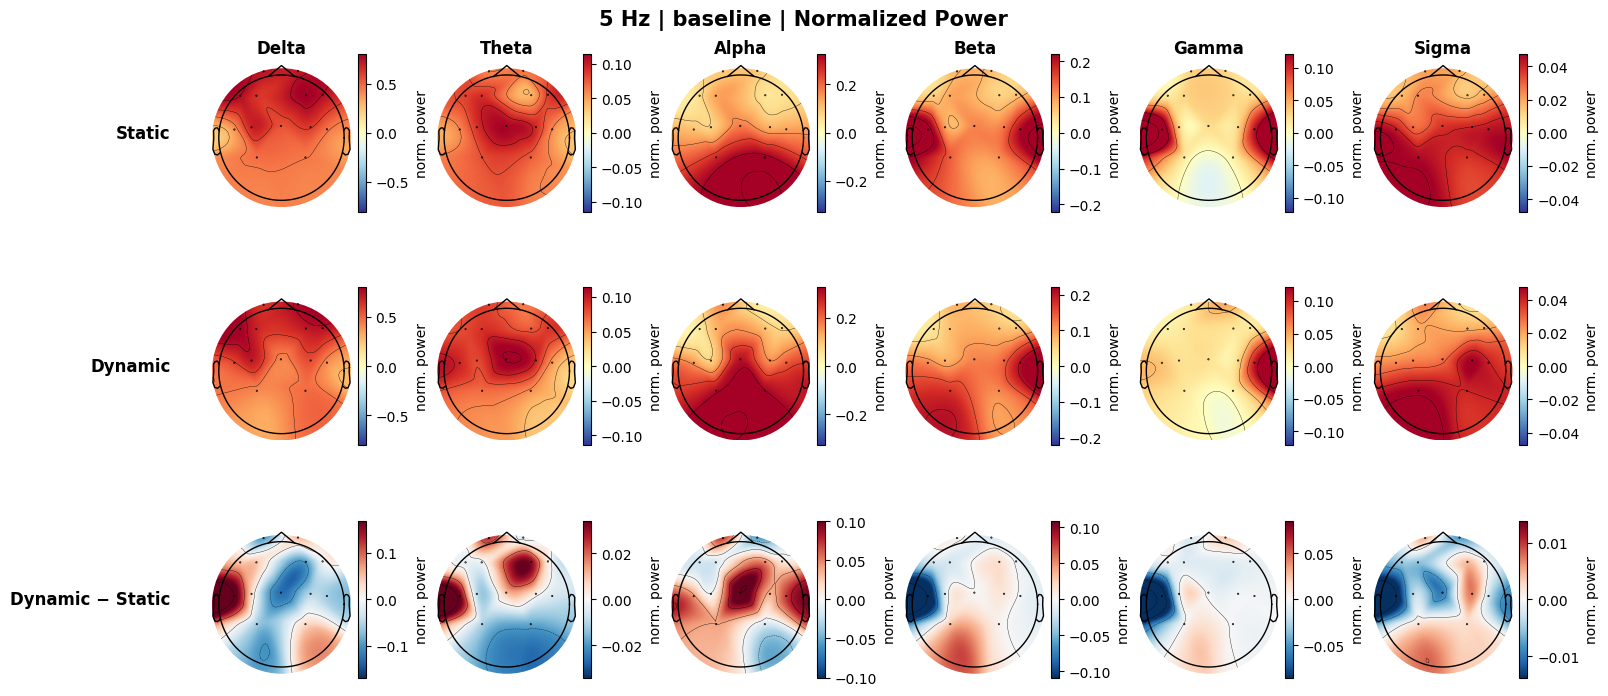

    Saved: figures/Power_5Hz_baseline.png
    Saved: figures/Power_5Hz_stimulation_1.png
    Saved: figures/Power_5Hz_recovery_1.png
    Saved: figures/Power_10Hz_baseline.png
    Saved: figures/Power_10Hz_stimulation_1.png
    Saved: figures/Power_10Hz_recovery_1.png
    Saved: figures/Power_20Hz_baseline.png
    Saved: figures/Power_20Hz_stimulation_1.png
    Saved: figures/Power_20Hz_recovery_1.png
    Saved: figures/Power_25Hz_baseline.png
    Saved: figures/Power_25Hz_stimulation_1.png
    Saved: figures/Power_25Hz_recovery_1.png
    Saved: figures/Power_40Hz_baseline.png
    Saved: figures/Power_40Hz_stimulation_1.png
    Saved: figures/Power_40Hz_recovery_1.png
Done


In [15]:
# Figure: normalized power topomap per stage 
from eeg_utils.viz import plot_topo

# ===== CONFIG =====
HZS = df_power['Hz'].unique().tolist()
ROW_CMAPS  = ['RdYlBu_r', 'RdYlBu_r', 'RdBu_r']
ROW_LABELS = ['Static', 'Dynamic', 'Dynamic − Static'] # Do not change 
temp = mne.read_epochs(df_meta.loc[0,'epo_path'], verbose="ERROR")
info = temp.pick('eeg').info
CHS = info['ch_names']

# ===== Plotting =====
print("Plotting norm. power topomap figures...")
for i, (hz, stag) in enumerate(itertools.product(HZS, STAGES)):
    sub = df_power[
        (df_power['Hz']==hz) &
        (df_power['stage']==stag)
    ]
    pv_static = sub[sub['Stim_type']=='static'].pivot_table(values='power', index='ch', columns='band')
    pv_static = pv_static.reindex(CHS)
    pv_dynamic = sub[sub['Stim_type']=='dynamic'].pivot_table(values='power', index='ch', columns='band')
    pv_dynamic = pv_dynamic.reindex(CHS)
    if pv_static.empty or pv_dynamic.empty:
        continue

    pv_diff = pv_dynamic-pv_static
    data = [pv_static, pv_dynamic, pv_diff]

    # compute vlim for cbar
    vlim_diff = [float(np.percentile(np.abs(pv_diff[band].values), 97))
                for band in BANDS] 
    vlim_sd = [float(np.percentile(np.abs(np.concatenate([pv_static[band].values, pv_dynamic[band].values])), 97))
        for band in BANDS]
    vlims = np.stack([vlim_sd, vlim_sd, vlim_diff])

    fig, axes = plt.subplots(len(ROW_LABELS), len(BANDS), 
                                figsize = (16, 7),
                                constrained_layout=True)
    axes_2d = np.atleast_2d(axes)
    for ri, (label, axes_row) in enumerate(zip(ROW_LABELS, axes_2d)):
        for ci, (ax, band) in enumerate(zip(axes_row, BANDS)):
            values = data[ri][band].values
            vlim = vlims[ri, ci]
            _, ax, im = plot_topo(values, info, 
                                    ax = ax, vlim=(-vlim, vlim),
                                    cmap = ROW_CMAPS[ri])
            fig.colorbar(im, ax=ax, shrink=0.7, label="norm. power")
            if ri == 0:
                ax.set_title(band, fontsize=12, fontweight='bold', pad=4)
            if ci == 0:
                ax.annotate(ROW_LABELS[ri], 
                            xy = (-0.3, 0.5), xycoords = 'axes fraction',
                            fontsize = 12, fontweight='bold',
                            ha = 'right', va = 'center'
                            )
    fig.suptitle(
        f"{hz} Hz | {stag} | Normalized Power", fontsize=15, fontweight='bold', y=1.01
        )
    
    stage_fn = stag.replace(" ", "_") # Sanitize stage name for filename (space → _)
    png_path = f"{fig_path}/Power_{hz}Hz_{stage_fn}.png"
    fig.savefig(png_path, dpi=150, bbox_inches="tight")
    if i == 0: # preview 
        plt.show()
    plt.close(fig)
    print(f"    Saved: {png_path}")
print("Done")

Δdynamic - Δstatic (change from baseline) 해석 시:
- 양수: Δdynamic > Δstatic (dynamic 쪽 '변화'가 더 큼)
- 음수: Δstatic > Δdynamic (static 쪽 '변화'가 더 큼

*각각이 baseline 대비 증가/감소(절대적 방향)했는지 알 수 없음

Plotting delta norm. power topomap figures...


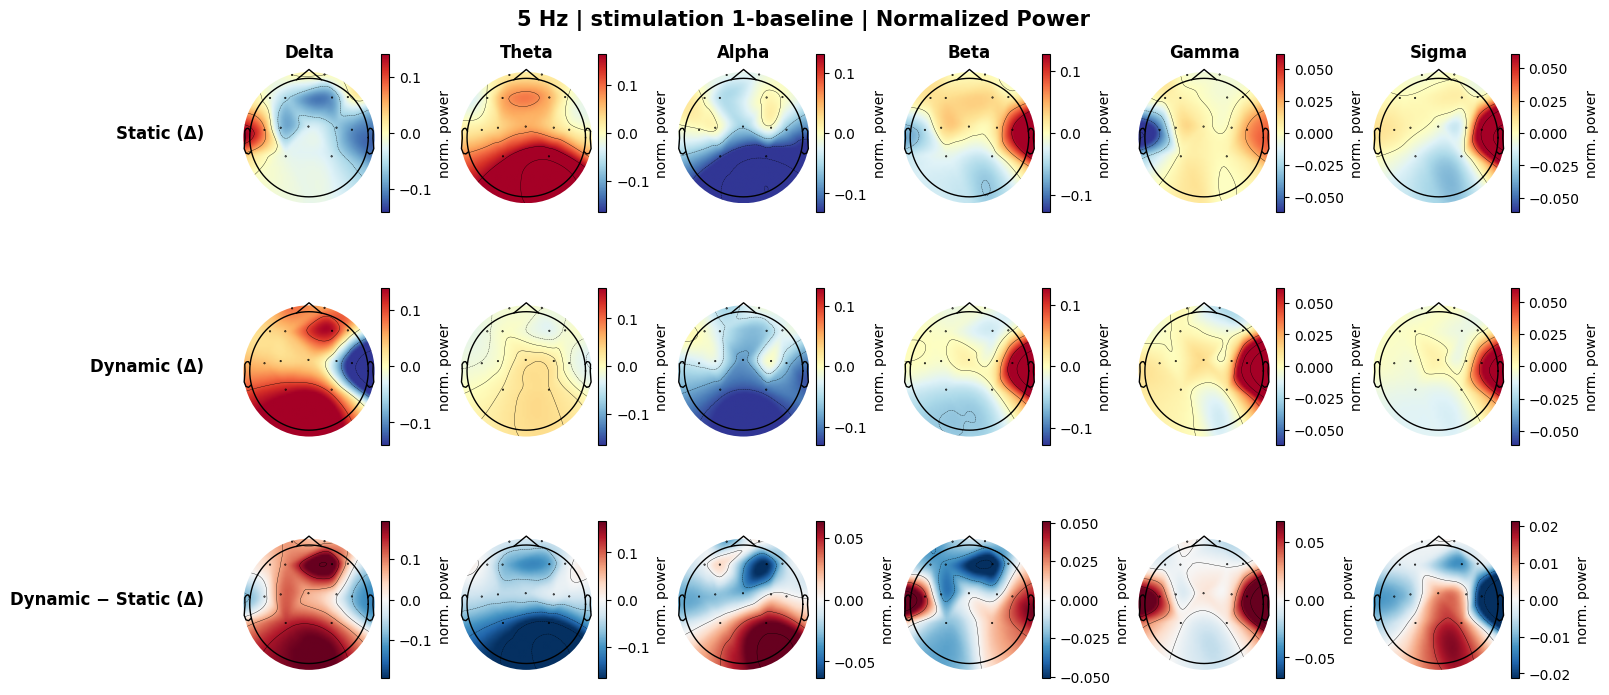

    Saved: figures/Power_5Hz_stimulation_1-baseline.png
    Saved: figures/Power_5Hz_recovery_1-baseline.png
    Saved: figures/Power_10Hz_stimulation_1-baseline.png
    Saved: figures/Power_10Hz_recovery_1-baseline.png
    Saved: figures/Power_20Hz_stimulation_1-baseline.png
    Saved: figures/Power_20Hz_recovery_1-baseline.png
    Saved: figures/Power_25Hz_stimulation_1-baseline.png
    Saved: figures/Power_25Hz_recovery_1-baseline.png
    Saved: figures/Power_40Hz_stimulation_1-baseline.png
    Saved: figures/Power_40Hz_recovery_1-baseline.png
Done


In [16]:
# Figure: delta normalized power(change from baseline) topomap per stage

# ===== CONFIG ======
HZS = df_power['Hz'].unique().tolist()
ROW_CMAPS  = ['RdYlBu_r', 'RdYlBu_r', 'RdBu_r']
ROW_LABELS = ['Static (Δ)', 'Dynamic (Δ)', 'Dynamic − Static (Δ)'] # Do not change 
BASE = 'baseline'
TARG = ['stimulation 1', 'recovery 1']

# ===== compute TARG-BASE =====
delta_pow = dict()
for (hz, stim_type), g in df_power.groupby(['Hz', 'Stim_type']):
    rows = []
    for band, gg in g.groupby('band'):
        pv = gg.pivot_table(values='power', index='ch', columns='stage')
        pv = pv.reindex(CHS)
        row = {"band": band}
        for targ in TARG:
            key = f"{targ}-{BASE}" 
            row[key] = (pv[targ] - pv[BASE]).values
        rows.append(row)
    delta_pow[(hz.item(), stim_type)] = pd.DataFrame(rows).set_index('band').reindex(BANDS)

# ===== Plotting =====
print("Plotting delta norm. power topomap figures...")
for i, (hz, stag) in enumerate(itertools.product(HZS, TARG)):
    df_static = delta_pow[(hz, 'static')][f'{stag}-{BASE}']
    df_dynamic = delta_pow[(hz, 'dynamic')][f'{stag}-{BASE}']
    if df_static.isna().all() or df_dynamic.isna().all():
        continue
    df_diff = df_dynamic - df_static
    data = [df_static, df_dynamic, df_diff]

    # compute vlim for cbar
    vlim_diff = [float(np.percentile(np.abs(df_diff.loc[band, ]), 97))
                for band in BANDS]
    vlim_sd = [float(np.percentile(np.abs(np.concatenate([df_static.loc[band, ], df_dynamic.loc[band, ]])), 97))
        for band in BANDS]
    vlims = np.stack([vlim_sd, vlim_sd, vlim_diff])

    fig, axes = plt.subplots(len(ROW_LABELS), len(BANDS), 
                                figsize = (16, 7),
                                constrained_layout=True)
    axes_2d = np.atleast_2d(axes)
    for ri, (label, axes_row) in enumerate(zip(ROW_LABELS, axes_2d)):
        for ci, (ax, band) in enumerate(zip(axes_row, BANDS)):
            values = data[ri].loc[band, ]
            vlim = vlims[ri, ci]
            _, ax, im = plot_topo(values, info, 
                                    ax = ax, vlim=(-vlim, vlim),
                                    cmap = ROW_CMAPS[ri])
            fig.colorbar(im, ax=ax, shrink=0.7, label="norm. power")
            if ri == 0:
                ax.set_title(band, fontsize=12, fontweight='bold', pad=4)
            if ci == 0:
                ax.annotate(ROW_LABELS[ri], 
                            xy = (-0.3, 0.5), xycoords = 'axes fraction',
                            fontsize = 12, fontweight='bold',
                            ha = 'right', va = 'center'
                            )
    fig.suptitle(
        f"{hz} Hz | {stag}-{BASE} | Normalized Power", fontsize=15, fontweight='bold', y=1.01
        )
    
    stage_fn = stag.replace(" ", "_")
    png_path = f"{fig_path}/Power_{hz}Hz_{stage_fn}-{BASE}.png"
    fig.savefig(png_path, dpi=150, bbox_inches="tight")
    if i == 0: # preview
        plt.show()
    plt.close(fig)
    print(f"    Saved: {png_path}")
print("Done")

### Combined Results
  경향성은 한 눈에 파악하기 위한 pie chart

#### Outer ring
- A1: baseline 대비 모든 조건(dynamic/static) 지표가 증가했으며 그 증가량이 static 조건보다 dynamic 조건에서 큰 경우
- A2: baseline 대비 모든 조건(dynamic/static) 지표가 증가했으며 그 증가량이 dynamic 조건보다 static 조건에서 큰 경우
- B1: baseline 대비 모든 조건(dynamic/static) 지표가 감소했으며 그 감소량이 static 조건보다 dynamic 조건에서 큰 경우
- B2: baseline 대비 모든 조건(dynamic/static) 지표가 감소했으며 그 감소량이 dynamic 조건보다 static 조건에서 큰 경우

-> A1/2 & B1/2: 자극의 효과의 방향이 조건에서 모두 동일하되 어떤 조건이 그 효과를 더 극대화하는가?
- C1: baseline 대비 static 조건에서는 지표가 증가하고 dynamic 조건에서는 감소한 경우
- C2: baseline 대비 static 조건에서는 지표가 감소하고 dynamic 조건에서는 증가한 경우

-> C1/2: 효과 크기 문제는 차치하고 효과의 방향이 다른 상황

#### Inset bar graphs
- “D > S” (A1 + B1): static 조건보다 dynamic 조건에서 효과 크기가 더 큰 경우(방향성 동일)
- “S > D” (A2 + B2): dynamic 조건보다 static 조건에서 효과 크기가 더 큰 경우(방향성 동일)
- “Diff” (C1 + C2): static과 dynamic 조건에서 효과의 방향(증가/감소)가 다른 채널의 비율 

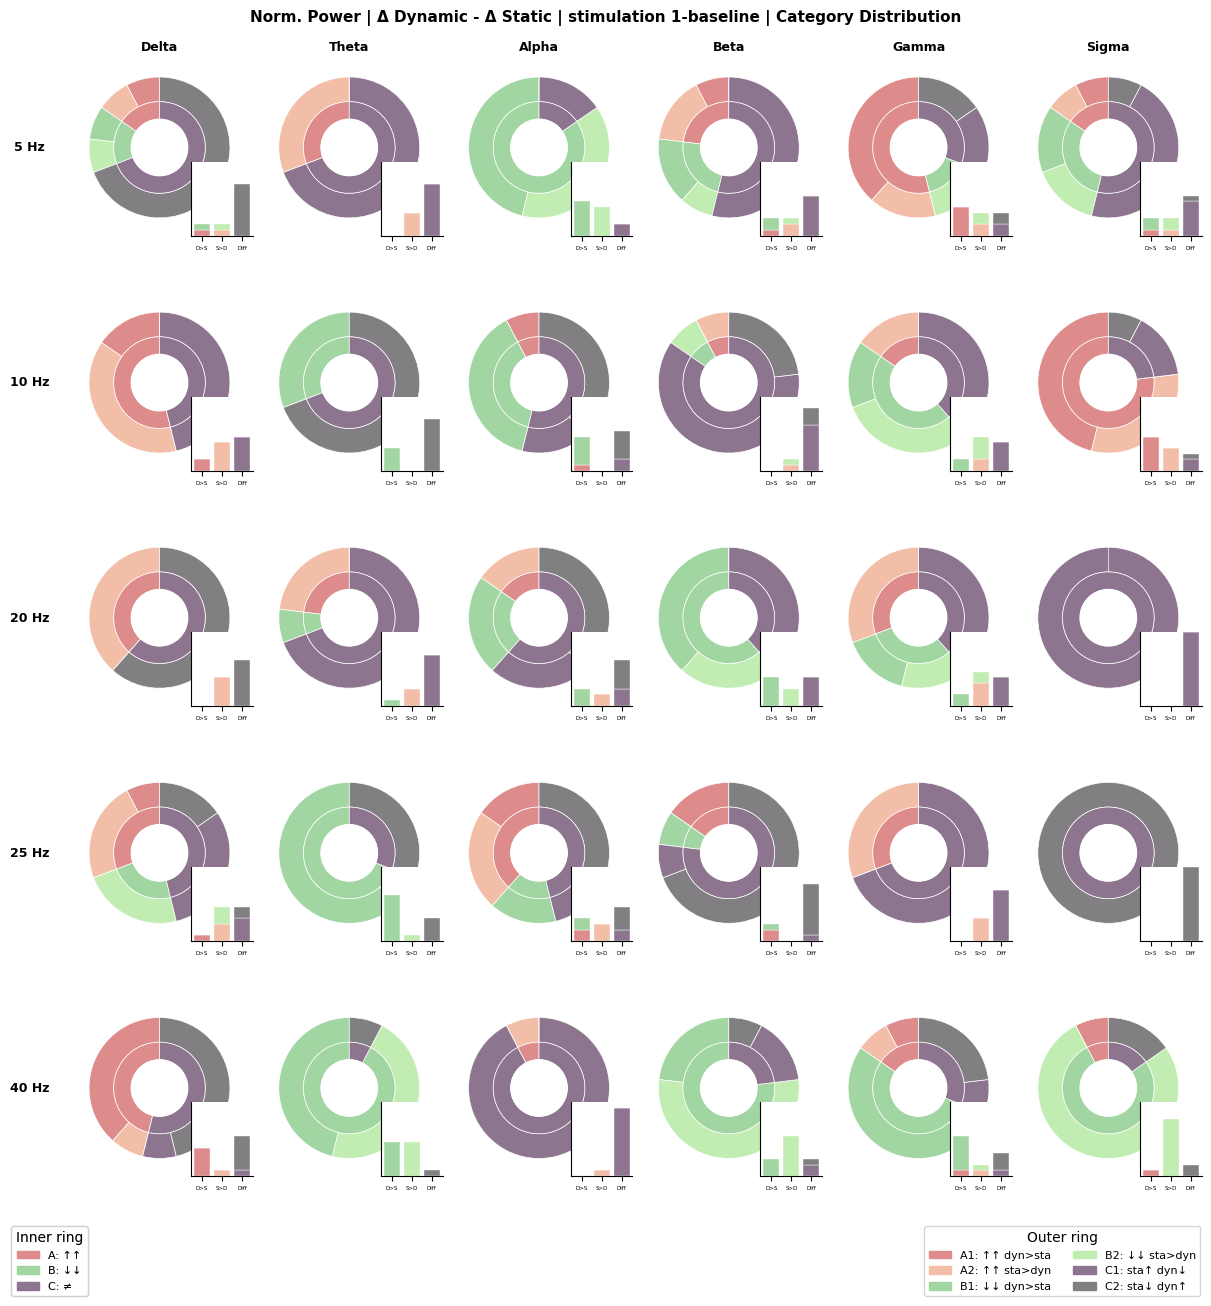

    Saved: figures/Power_deltaDynamic-Static_stimulation 1_pie.png
    Saved: figures/Power_deltaDynamic-Static_recovery 1_pie.png


In [17]:
# Figure: nested donut pie chart — norm. power category distribution per hz × band × stag

# ===== CONFIG =====
BASE = 'baseline'
TARG = ['stimulation 1', 'recovery 1']

CATEGORIES = ['A1', 'A2', 'B1', 'B2', 'C1', 'C2']
CAT_LABELS = ['A1: ↑↑ dyn>sta', 'A2: ↑↑ sta>dyn',
              'B1: ↓↓ dyn>sta', 'B2: ↓↓ sta>dyn',
              'C1: sta↑ dyn↓',  'C2: sta↓ dyn↑']
CAT_COLORS = ['#DD8B8B', '#F2BEA7', '#A1D6A2', '#C2EDB2', '#8D748F', '#817F82']

PARENT_MAP    = {'A1': 'A', 'A2': 'A', 'B1': 'B', 'B2': 'B', 'C1': 'C', 'C2': 'C'}
PARENT_COLORS = {'A': '#DD8B8B', 'B': '#A1D6A2', 'C': '#8D748F'}
PARENT_ORDER  = ['A', 'B', 'C']
PARENT_LABELS = ['A: ↑↑', 'B: ↓↓', 'C: ≠']

STACK_PAIRS  = [('A1', 'B1'), ('A2', 'B2'), ('C1', 'C2')]
STACK_COLORS = [('#DD8B8B', '#A1D6A2'), ('#F2BEA7', '#C2EDB2'), ('#8D748F', '#817F82')]

HZS_pw = df_power['Hz'].unique().tolist()

def categorize(ds, dd):
    if ds > 0 and dd > 0:
        return 'A1' if dd > ds else 'A2'
    elif ds < 0 and dd < 0:
        return 'B1' if dd > ds else 'B2'
    elif ds > 0 and dd < 0:
        return 'C1'
    else:
        return 'C2'

# ===== Plotting =====
for i, stag in enumerate(TARG):
    fig, axes = plt.subplots(len(HZS_pw), len(BANDS),
                             figsize=(12, 12),
                             subplot_kw=dict(aspect='equal'), layout='constrained')
    axes = np.atleast_2d(axes)

    for ri, hz in enumerate(HZS_pw):
        # baseline
        base_s = df_power[(df_power['Hz']==hz) & (df_power['Stim_type']=='static')  & (df_power['stage']==BASE)][['ch','band','power']]
        base_d = df_power[(df_power['Hz']==hz) & (df_power['Stim_type']=='dynamic') & (df_power['stage']==BASE)][['ch','band','power']]
        # target
        targ_s = df_power[(df_power['Hz']==hz) & (df_power['Stim_type']=='static')  & (df_power['stage']==stag)][['ch','band','power']]
        targ_d = df_power[(df_power['Hz']==hz) & (df_power['Stim_type']=='dynamic') & (df_power['stage']==stag)][['ch','band','power']]

        df_s = targ_s.merge(base_s, on=['ch','band'], suffixes=('_targ','_base'))
        df_s['delta_static'] = df_s['power_targ'] - df_s['power_base']

        df_d = targ_d.merge(base_d, on=['ch','band'], suffixes=('_targ','_base'))
        df_d['delta_dynamic'] = df_d['power_targ'] - df_d['power_base']

        df = df_s[['ch','band','delta_static']].merge(
            df_d[['ch','band','delta_dynamic']], on=['ch','band'])
        df['category'] = df.apply(lambda r: categorize(r['delta_static'], r['delta_dynamic']), axis=1)

        for ci, band in enumerate(BANDS):
            ax = axes[ri, ci]
            data = df[df['band'] == band]
            total = len(data)

            outer_counts = [len(data[data['category'] == c]) for c in CATEGORIES]
            inner_counts = [len(data[data['category'].map(PARENT_MAP) == p]) for p in PARENT_ORDER]

            ax.pie(outer_counts, colors=CAT_COLORS, startangle=90,
                   radius=1.0, wedgeprops=dict(edgecolor='white', linewidth=0.5, width=0.35))
            ax.pie(inner_counts, colors=[PARENT_COLORS[p] for p in PARENT_ORDER], startangle=90,
                   radius=0.65, wedgeprops=dict(edgecolor='white', linewidth=0.5, width=0.25))
            ax.add_patch(plt.Circle((0, 0), 0.4, color='white', zorder=3))

            inset = ax.inset_axes([0.68, 0.0, 0.35, 0.42])
            counts = {c: len(data[data['category'] == c]) / total if total else 0 for c in CATEGORIES}
            for xi, ((bot_cat, top_cat), (bot_col, top_col)) in enumerate(zip(STACK_PAIRS, STACK_COLORS)):
                inset.bar(xi, counts[bot_cat], color=bot_col, edgecolor='white', linewidth=0.3)
                inset.bar(xi, counts[top_cat], bottom=counts[bot_cat], color=top_col,
                          edgecolor='white', linewidth=0.3)
            inset.set_ylim(0, 1)
            inset.set_yticks([])
            inset.set_xticks([0, 1, 2])
            inset.set_xticklabels(['D>S', 'S>D', 'Diff'], fontsize=4)
            inset.spines[['top', 'right']].set_visible(False)

            if ri == 0:
                ax.set_title(band, fontsize=9, fontweight='bold')
            if ci == 0:
                ax.set_ylabel(f"{hz} Hz", fontsize=9, fontweight='bold',
                              rotation=0, labelpad=30, va='center')

    outer_handles = [plt.matplotlib.patches.Patch(color=c, label=l)
                     for c, l in zip(CAT_COLORS, CAT_LABELS)]
    inner_handles = [plt.matplotlib.patches.Patch(color=PARENT_COLORS[p], label=l)
                     for p, l in zip(PARENT_ORDER, PARENT_LABELS)]
    leg1 = fig.legend(handles=inner_handles, loc='lower left', fontsize=8,
                      title='Inner ring', bbox_to_anchor=(0.0, -0.08))
    leg2 = fig.legend(handles=outer_handles, loc='lower right', fontsize=8,
                      title='Outer ring', ncol=2, bbox_to_anchor=(1.0, -0.08))
    fig.add_artist(leg1)
    fig.suptitle(f"Norm. Power | Δ Dynamic - Δ Static | {stag}-{BASE} | Category Distribution",
                 fontsize=11, fontweight='bold')
    png_path = f"{fig_path}/Power_deltaDynamic-Static_{stag}_pie.png"
    fig.savefig(png_path, dpi=150, bbox_inches='tight')
    if i == 0:  # preview
        plt.show()
    plt.close(fig)
    print(f"    Saved: {png_path}")

# FC Analysis

Method: 
- Coherence (Coh)
- Phase Locking Value (PLV) 
- Phase Lag Index (PLI)
- Weighted Phase Lag Index (wPLI)
- Amplitude Envelope Correlation (AEC)

In [4]:
df_use = df_meta[df_meta['Use_flag']].reset_index(drop=True)
df_use

,Hz,Stim_type,csv_path,raw_fif_path,raw_fin_fif_path,epo_path,Use_flag,BadChannels
0,5,dynamic,Data/5hz_dynamic.csv,Data/5hz_dynamic_raw.fif,Data/5hz_dynamic_raw_fin.fif,Data/5hz_dynamic_epo.fif,True,None
1,5,static,Data/5hz_static.csv,Data/5hz_static_raw.fif,Data/5hz_static_raw_fin.fif,Data/5hz_static_epo.fif,True,None
2,10,dynamic,Data/10hz_dynamic_2.csv,Data/10hz_dynamic_2_raw.fif,Data/10hz_dynamic_2_raw_fin.fif,Data/10hz_dynamic_2_epo.fif,True,"F4, C4"
3,10,static,Data/10hz_static.csv,Data/10hz_static_raw.fif,Data/10hz_static_raw_fin.fif,Data/10hz_static_epo.fif,True,F3
4,20,dynamic,Data/20hz_dynamic.csv,Data/20hz_dynamic_raw.fif,Data/20hz_dynamic_raw_fin.fif,Data/20hz_dynamic_epo.fif,True,"F4, C4"
5,20,static,Data/20hz_static.csv,Data/20hz_static_raw.fif,Data/20hz_static_raw_fin.fif,Data/20hz_static_epo.fif,True,Cz
6,25,dynamic,Data/25hz_dynamic.csv,Data/25hz_dynamic_raw.fif,Data/25hz_dynamic_raw_fin.fif,Data/25hz_dynamic_epo.fif,True,P3
7,25,static,Data/25hz_static.csv,Data/25hz_static_raw.fif,Data/25hz_static_raw_fin.fif,Data/25hz_static_epo.fif,True,"F3, F4"
8,40,dynamic,Data/40hz_dynamic.csv,Data/40hz_dynamic_raw.fif,Data/40hz_dynamic_raw_fin.fif,Data/40hz_dynamic_epo.fif,True,Cz
9,40,static,Data/40hz_static_2.csv,Data/40hz_static_2_raw.fif,Data/40hz_static_2_raw_fin.fif,Data/40hz_static_2_epo.fif,True,P4


In [6]:
from eeg_utils.eeg_preprocess import EEG_Preprocessor, EEG_Epocher
from eeg_utils.eeg_analysis import FCAnalyzer

# ===== CONFIG =====
spectral_FCs:list = ['coh', 'wpli', 'pli', 'plv']
FC_EPOCH_LEN = 10.0 # 5 cycles for 0.5 Hz infra slow를 버리고 1Hz부터 시작하면 4~5 sec epoch 사용가능함. 생각 필요
FC_OVERLAP = FC_EPOCH_LEN/2

compute_AEC = True
AEC_EPOCH_LEN = 20.0 # 0.5Hz도 커버할 거면 60 sec 이상인게 좋음...
AEC_OVERLAP = 0.0

all_freqs = [f for band in freqs_bands.values() for f in band]
fmin, fmax = min(all_freqs), max(all_freqs)
BANDS = list(freqs_bands.keys())
STAGES = ["baseline", "stimulation 1", "recovery 1"]
MIN_EPOCHS = 10 # 보통은 50개 이상...
FC_out_path = f"{f_path}/FC_DB.pkl"

METHODS = spectral_FCs + ['AEC'] if compute_AEC else spectral_FCs
print(f"Covered methods: {', '.join(METHODS)}\n")

if Path(FC_out_path).exists():
    print(f"{FC_out_path} already exists.")
    print(f"Loading {FC_out_path}...")
    with open(FC_out_path, 'rb') as f:
        out = pickle.load(f)
    missing = [m for m in METHODS if m not in out.keys()]
    if len(missing)>0:
        print(f"    {', '.join(missing)} should be computed\n")
else:
    out = defaultdict(dict)
    missing = METHODS

# ===== Compute spectral FCs =====
for method in [m for m in missing if m != 'AEC']:
    print(f"Computing {method}...")
    for i, row in tqdm(df_use.iterrows(), total=len(df_use), desc="    processing"):
        hz = row['Hz']
        stim_type = row['Stim_type']
        raw_path = row['raw_fin_fif_path']
        with mne.use_log_level("ERROR"):
            raw = mne.io.read_raw_fif(raw_path, preload=True, verbose="ERROR")
            epocher = (
                EEG_Epocher(raw)
                .make_epochs(epoch_len=FC_EPOCH_LEN, overlap=FC_OVERLAP, verbose=False)
            )
        epochs = epocher.epochs.copy().pick('eeg')
        for stage in STAGES:
            ep = epochs[f'stage == "{stage}"']
            fc = FCAnalyzer(epochs=ep)
            fc.compute_spectral_FC(
                method = method,
                mode = 'multitaper',
                fmin = fmin,
                fmax = fmax, 
                faverage = False,
                mt_adaptive = True,
                n_epochs_min = MIN_EPOCHS,
                verbose='WARNING'
            )

            df_out = fc.conn_to_df(method=method)
            df_out = fc.to_band(df_out, freqs_band = freqs_bands)
            df_out.drop(columns='freq', inplace=True)
            out[method][(hz, stim_type, stage)] = df_out.groupby(['ch1', 'ch2', 'band'])['value'].mean().reset_index()

# ===== Compute AEC =====
if 'AEC' in missing:
    print(f"Computing AEC...")
    for i, row in tqdm(df_use.iterrows(), total=len(df_use), desc="    processing"):
        hz = row['Hz']
        stim_type = row['Stim_type']
        raw_path = row['raw_fin_fif_path']
        with mne.use_log_level("ERROR"):
            raw = mne.io.read_raw_fif(raw_path, preload=True, verbose="ERROR")
            for stage in STAGES:
                df_out_list = []
                for band, (lf, hf) in freqs_bands.items():
                    pre = EEG_Preprocessor(raw)
                    pre.bandpass_filter(l_freq=lf, h_freq=hf,
                                        notch_freq = None)
                    raw_filt = pre.raw_filt
                    epocher = (
                        EEG_Epocher(raw_filt)
                        .make_epochs(epoch_len=AEC_EPOCH_LEN, overlap=AEC_OVERLAP,
                                     verbose=False)
                    )
                    epochs = epocher.epochs.copy().pick('eeg')
                    ep = epochs[f'stage == "{stage}"']
                    fc = FCAnalyzer(epochs=ep) 
                    fc.compute_AEC(n_epochs_min = 0) # 40 Hz dynamic recovery 1 epoch 수 세개 밖에 안 됨
                    df_out = fc.conn_to_df(method='AEC', band=band)
                    df_out_list.append(df_out)
                out['AEC'][(hz, stim_type, stage)] = pd.concat(df_out_list, ignore_index=True)
with open(FC_out_path, 'wb') as f:
    pickle.dump(out, f)
print("Done")

Covered methods: coh, wpli, pli, plv, AEC

Data/FC_DB.pkl already exists.
Loading Data/FC_DB.pkl...
Done


Plotting coh topomap figures...


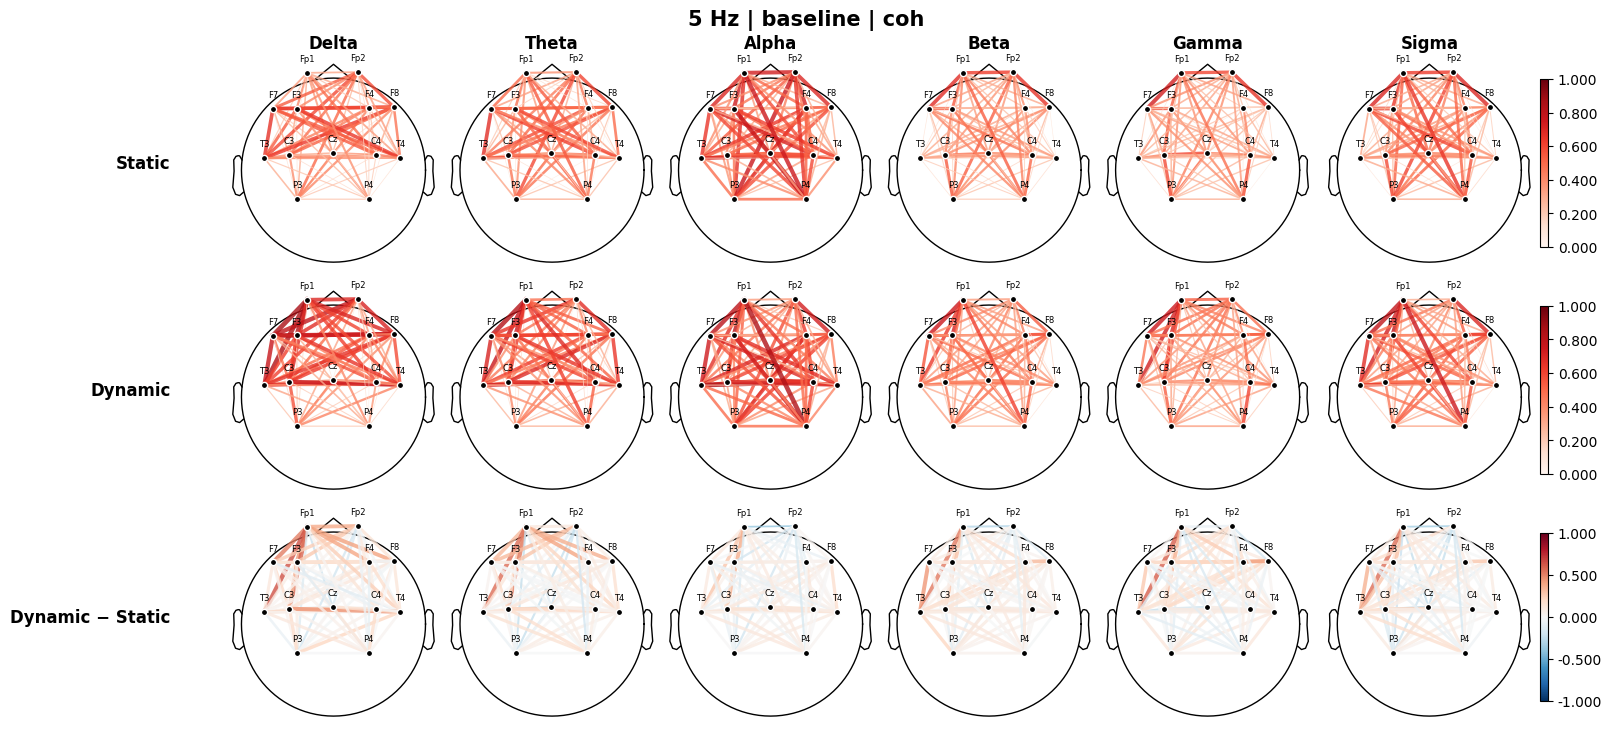

    Saved: figures/coh_*Hz_*.png
Plotting wpli topomap figures...
    Saved: figures/wpli_*Hz_*.png
Plotting pli topomap figures...
    Saved: figures/pli_*Hz_*.png
Plotting plv topomap figures...
    Saved: figures/plv_*Hz_*.png
Plotting AEC topomap figures...
    Saved: figures/AEC_*Hz_*.png
Done


In [10]:
# Figure: normalized FC topomap per stage 
from mne_connectivity.viz import plot_connectivity_circle
from mne.viz import circular_layout
from eeg_utils.viz import plot_FC_topo
import seaborn as sns

# ===== COFIG =====
ROW_CMAPS  = ['Reds', 'Reds', 'RdBu_r']
ROW_LABELS = ['Static', 'Dynamic', 'Dynamic − Static'] # Do not change 
VALUE_LABELS = ['value_static', 'value_dynamic', 'dynamic-static']
VLIMS = [(0, 1), (0, 1), (-1, 1)] 
HZS = np.sort(df_use['Hz'].unique().tolist())
VIS = 'topo' # 'topo' or 'circle' or 'heatmap'

lh_labels = ['Fp1', 'F7', 'F3', 'T3', 'C3', 'P3', 'O1']  # left hem, 전→후
rh_labels = ['Fp2', 'F8', 'F4', 'T4', 'C4', 'P4', 'O2']  # righ hem, 전→후
c_labels = ['Cz']
lh_labels = [ch for ch in lh_labels if ch in CHS]
rh_labels = [ch for ch in rh_labels if ch in CHS]
c_labels = [ch for ch in c_labels if ch in CHS]
node_order = lh_labels + c_labels + rh_labels[::-1]  # LH 정순 + 중앙 + RH 역순
node_angles = circular_layout(
    CHS,
    node_order,
    start_pos=90,
    group_boundaries=[0, len(lh_labels), len(lh_labels)+len(c_labels)]
)    

# ===== Plotting =====
for i, method in enumerate(METHODS):
    print(f"Plotting {method} topomap figures...")
    for j, (hz, stag) in enumerate(itertools.product(HZS, STAGES)):
        df_static = out[method][(hz, 'static', stag)]
        df_dynamic = out[method][(hz, 'dynamic', stag)]
        df_merged = df_static.merge(df_dynamic, on=['ch1', 'ch2', 'band'], suffixes=('_static', '_dynamic'))
        df_merged['dynamic-static'] = df_merged['value_dynamic']-df_merged['value_static']
        
        if VIS == 'circle':
            fig, axes = plt.subplots(len(ROW_LABELS), len(BANDS),
                                    figsize=(16, 7),
                                    subplot_kw=dict(polar=True),
                                    constrained_layout=True)
        elif VIS == 'topo' or VIS =='heatmap':
            fig, axes = plt.subplots(len(ROW_LABELS), len(BANDS),
                                    figsize=(16, 7),
                                    constrained_layout=True)
        else:
            raise ValueError("'VIS' should be either 'topo', 'circle', or 'heatmap'")
        
        axes_2d = np.atleast_2d(axes)
        for ri, (label, axes_row) in enumerate(zip(ROW_LABELS, axes_2d)):
            for ci, (ax, band) in enumerate(zip(axes_row, BANDS)):
                data = df_merged[df_merged['band']==band]
                M = (data.pivot_table(index='ch1', columns='ch2', values=VALUE_LABELS[ri])
                        .reindex(index=CHS, columns=CHS)
                        .to_numpy())
                
                if VIS == 'circle':
                    _, ax = plot_connectivity_circle(
                        M,
                        CHS, 
                        n_lines = 300,
                        node_angles=node_angles,
                        facecolor='white', textcolor='black',
                        node_linewidth = 1,
                        show=False,
                        vmin = VLIMS[ri][0],
                        vmax = VLIMS[ri][1],
                        ax=ax,
                        colormap = ROW_CMAPS[ri]
                    )

                elif VIS == 'topo':
                    _, ax = plot_FC_topo(
                        M, info, CHS,
                        ax = ax,
                        vlim = (VLIMS[ri][0], VLIMS[ri][1]),
                        cmap = ROW_CMAPS[ri],
                        colorbar = True if ci == len(BANDS)-1 else False
                    )
                
                elif VIS == 'heatmap':
                    ax = sns.heatmap(
                        M,
                        xticklabels = CHS, yticklabels = CHS,
                        vmin = VLIMS[ri][0], vmax = VLIMS[ri][1],
                        cmap = ROW_CMAPS[ri], 
                        cbar = True if ci == len(BANDS)-1 else False,
                        ax = ax
                    )

                if ri == 0:
                    ax.set_title(band, fontsize=12, fontweight='bold', pad=4)
                if ci == 0:
                    ax.annotate(ROW_LABELS[ri],
                                xy = (-0.3, 0.5), xycoords='axes fraction',
                                fontsize=12, fontweight='bold', 
                                ha = 'right',  va = 'center')
        fig.suptitle(
            f"{hz} Hz | {stag} | {method}", fontsize=15, fontweight='bold', y=1.03
        )
        stage_fn = stag.replace(" ", "_")
        png_path = f"{fig_path}/{method}_{hz}Hz_{stage_fn}.png"
        fig.savefig(png_path, dpi=150, bbox_inches='tight')
        if i == 0 and j ==0: # preview
            plt.show()
        plt.close(fig)
    print(f"    Saved: {fig_path}/{method}_*Hz_*.png")
print("Done")

Plotting delta coh topomap figures...


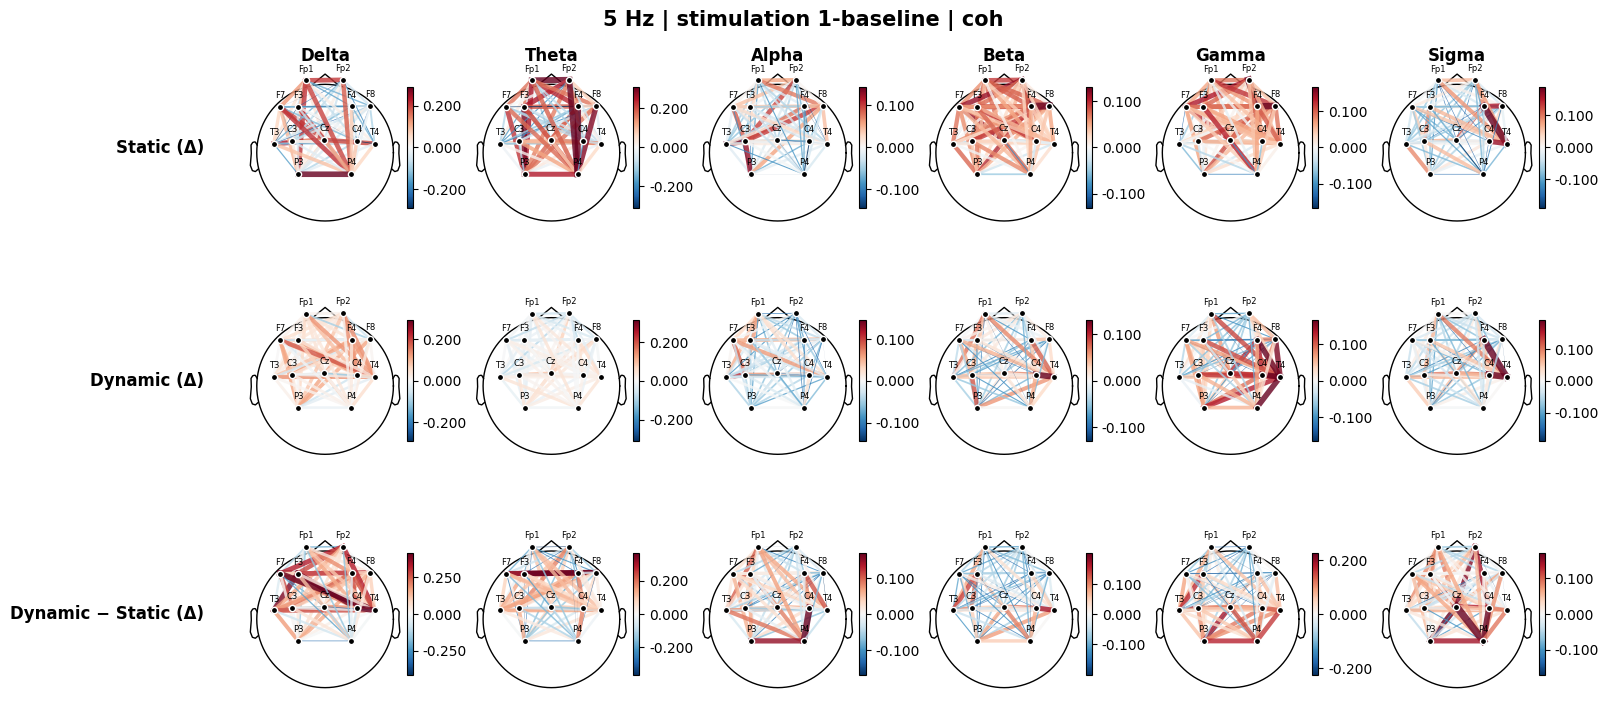

    Saved: figures/coh_*Hz_*-baseline.png
Plotting delta wpli topomap figures...
    Saved: figures/wpli_*Hz_*-baseline.png
Plotting delta pli topomap figures...
    Saved: figures/pli_*Hz_*-baseline.png
Plotting delta plv topomap figures...
    Saved: figures/plv_*Hz_*-baseline.png
Plotting delta AEC topomap figures...
    Saved: figures/AEC_*Hz_*-baseline.png
Done


In [23]:
# Figure: delta normalized FC(change from baseline) topomap per stage
# ===== CONFIG =====
BASE = 'baseline'
TARG = ['stimulation 1', 'recovery 1']

ROW_CMAPS  = ['RdBu_r', 'RdBu_r', 'RdBu_r']
ROW_LABELS = ['Static (Δ)', 'Dynamic (Δ)', 'Dynamic − Static (Δ)']
VALUE_LABELS = ['delta_static', 'delta_dynamic', 'dynamic-static']
VLIMS = [(-1, 1), (-1, 1), (-2, 2)]
USE_VLIMS = False 

# ===== Plotting =====
for i, method in enumerate(METHODS):
    print(f"Plotting delta {method} topomap figures...")
    for j, (hz, stag) in enumerate(itertools.product(HZS, TARG)):
        df_static_base = out[method][(hz, 'static', BASE)]
        df_dynamic_base = out[method][(hz, 'dynamic', BASE)]
        df_static_targ = out[method][(hz, 'static', stag)]
        df_dynamic_targ = out[method][(hz, 'dynamic', stag)]

        df_s = df_static_targ.merge(df_static_base, on=['ch1', 'ch2', 'band'], suffixes=('_targ', '_base'))
        df_s['delta_static'] = df_s['value_targ'] - df_s['value_base']

        df_d = df_dynamic_targ.merge(df_dynamic_base, on=['ch1', 'ch2', 'band'], suffixes=('_targ', '_base'))
        df_d['delta_dynamic'] = df_d['value_targ'] - df_d['value_base']

        df_merged = df_s[['ch1', 'ch2', 'band', 'delta_static']].merge(
            df_d[['ch1', 'ch2', 'band', 'delta_dynamic']],
            on=['ch1', 'ch2', 'band']
        )
        df_merged['dynamic-static'] = df_merged['delta_dynamic'] - df_merged['delta_static']

        fig, axes = plt.subplots(len(ROW_LABELS), len(BANDS),
                                    figsize=(16, 7),
                                    constrained_layout=True)
        axes_2d = np.atleast_2d(axes)
        for ri, (label, axes_row) in enumerate(zip(ROW_LABELS, axes_2d)):
            for ci, (ax, band) in enumerate(zip(axes_row, BANDS)):
                data = df_merged[df_merged['band'] == band]
                
                if not USE_VLIMS:
                    vlim_diff = float(np.percentile(np.abs(data['dynamic-static'].values), 97))
                    vlim_sd = float(np.percentile(np.abs(np.concatenate([data['delta_static'].values, data['delta_dynamic'].values])), 97))
                    cur_VLIMS = [(-vlim_sd, vlim_sd), (-vlim_sd, vlim_sd), (-vlim_diff, vlim_diff)]

                M = (data.pivot_table(index='ch1', columns='ch2', values=VALUE_LABELS[ri])
                        .reindex(index=CHS, columns=CHS)
                        .to_numpy())
                
                vlim = VLIMS[ri] if USE_VLIMS else cur_VLIMS[ri]
                colorbar = (not USE_VLIMS) or (USE_VLIMS and ci == len(BANDS)-1)
                _, ax = plot_FC_topo(
                    M, info, CHS,
                    ax=ax,
                    vlim = vlim,
                    cmap=ROW_CMAPS[ri],
                    colorbar = colorbar
                )
                if ri == 0:
                    ax.set_title(band, fontsize=12, fontweight='bold', pad=4)
                if ci == 0:
                    ax.annotate(ROW_LABELS[ri],
                                xy=(-0.3, 0.5), xycoords='axes fraction',
                                fontsize=12, fontweight='bold',
                                ha='right', va='center')
        fig.suptitle(
            f"{hz} Hz | {stag}-{BASE} | {method}", fontsize=15, fontweight='bold', y=1.03
        )
        stage_fn = stag.replace(" ", "_")
        png_path = f"{fig_path}/{method}_{hz}Hz_{stage_fn}-{BASE}.png"
        fig.savefig(png_path, dpi=150, bbox_inches='tight')
        if i == 0 and j == 0: # preview
            plt.show()
        plt.close(fig)
    print(f"    Saved: {fig_path}/{method}_*Hz_*-{BASE}.png")
print("Done")

### Exploration

Drawing coh delta dynamic - delta static distribution figure...


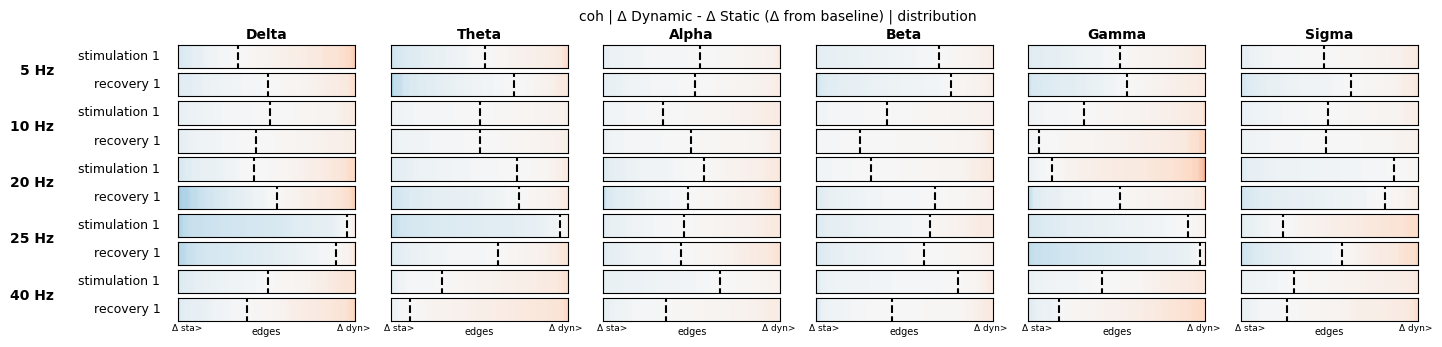

    Saved: figures/coh_deltaDynamic-Static_shade.png
Drawing wpli delta dynamic - delta static distribution figure...
    Saved: figures/wpli_deltaDynamic-Static_shade.png
Drawing pli delta dynamic - delta static distribution figure...
    Saved: figures/pli_deltaDynamic-Static_shade.png
Drawing plv delta dynamic - delta static distribution figure...
    Saved: figures/plv_deltaDynamic-Static_shade.png
Drawing AEC delta dynamic - delta static distribution figure...
    Saved: figures/AEC_deltaDynamic-Static_shade.png


In [24]:
# Figure: delta dynamic vs delta static (magnitude of changes from baseline) distribution
# ===== CONFIG =====
BASE = 'baseline'
TARG = ['stimulation 1', 'recovery 1']

CMAP = 'RdBu_r'
VLIM = (-2, 2)
n_edges = math.comb(len(CHS), 2)

# ===== Plotting =====
for i, method in enumerate(METHODS):
    print(f"Drawing {method} delta dynamic - delta static distribution figure...") 
    n_rows = len(HZS) * len(TARG)
    fig, axes = plt.subplots(n_rows, len(BANDS), figsize=(16,3.5))
    axes = np.atleast_2d(axes)
    for ri, (hz, stag) in enumerate(zip(np.repeat(HZS,2), TARG*len(HZS))):
        for ci, band in enumerate(BANDS):
            df_static_base = out[method][(hz, 'static', BASE)]
            df_dynamic_base = out[method][(hz, 'dynamic', BASE)]
            df_static_targ = out[method][(hz, 'static', stag)]
            df_dynamic_targ = out[method][(hz, 'dynamic', stag)]

            df_s = df_static_targ.merge(df_static_base, on=['ch1', 'ch2', 'band'], suffixes=('_targ', '_base'))
            df_s['delta_static'] = df_s['value_targ'] - df_s['value_base']

            df_d = df_dynamic_targ.merge(df_dynamic_base, on=['ch1', 'ch2', 'band'], suffixes=('_targ', '_base'))
            df_d['delta_dynamic'] = df_d['value_targ'] - df_d['value_base']

            df_merged = df_s[['ch1', 'ch2', 'band', 'delta_static']].merge(
                df_d[['ch1', 'ch2', 'band', 'delta_dynamic']],
                on=['ch1', 'ch2', 'band']
            )
            df_merged['dynamic-static'] = df_merged['delta_dynamic'] - df_merged['delta_static']
            
            data = df_merged[df_merged['band'] == band]
            M = (data.pivot_table(index='ch1', columns='ch2', values='dynamic-static')
                    .reindex(index=CHS, columns=CHS)
                    .to_numpy())
            values = np.sort(M[~np.isnan(M)]).reshape(1, -1)
            close0_idx = np.argmin(np.abs(values))

            ax = axes[ri, ci]
            ax.imshow(values, aspect='auto', cmap = CMAP, vmin = VLIM[0], vmax = VLIM[1])
            ax.axvline(x=close0_idx, ymin =-0.1, ymax=1.1, linestyle='--', c = 'black')
            ax.set_xticks([])
            ax.set_yticks([])

            if ri == 0: 
                ax.set_title(band, fontsize=10, fontweight='bold', pad=4)
            if ci == 0:
                ax.annotate(stag, xy=(-0.1, 0.5), xycoords='axes fraction',
                            fontsize=9, ha='right', va='center', rotation=0)
            if ci == 0 and ri % 2 == 0:
                ax.annotate(f"{hz} Hz", xy = (-0.7, -0.1), xycoords = "axes fraction",
                            fontsize=10, fontweight='bold',
                            ha = 'right', va = 'center')
            if ri == n_rows - 1:
                ax.set_xlabel("edges", fontsize=7)
                ax.annotate("Δ sta>", xy=(0.05, -0.3), xycoords = "axes fraction",
                            fontsize = 6.5, ha='center', va='center')
                ax.annotate("Δ dyn>", xy=(0.99, -0.3), xycoords = "axes fraction",
                            fontsize = 6.5, ha='center', va='center')
    fig.suptitle(f"{method} | Δ Dynamic - Δ Static (Δ from baseline) | distribution",
                fontsize=10, y=1.0)
    plt.subplots_adjust(top=0.9)
    png_path = f"{fig_path}/{method}_deltaDynamic-Static_shade.png"
    fig.savefig(png_path, dpi=150, bbox_inches='tight')
    if i == 0: # preview
        plt.show()
    plt.close(fig)
    print(f"    Saved: {png_path}")

Drawing AEC delta_static vs delta_dynamic connected dot plot...


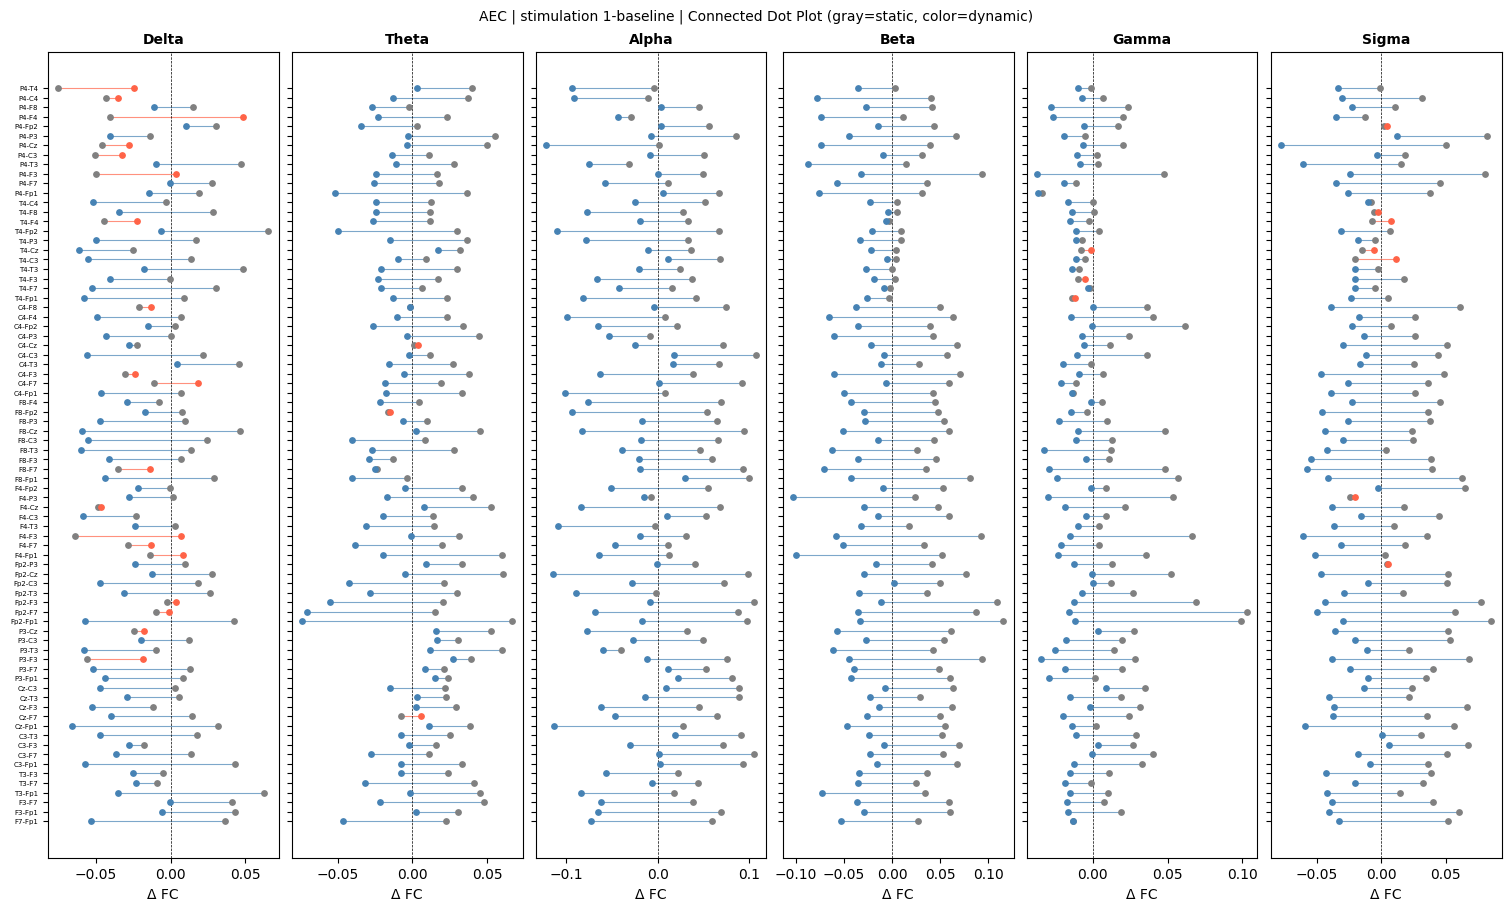

In [25]:
# Figure: connected dot plot (dumbbell) — delta_static vs delta_dynamic per edge
# ===== CONFIG =====
BASE = 'baseline'
TARG = ['stimulation 1', 'recovery 1']
n_edges = math.comb(len(CHS), 2)

# ===== Plotting =====
print(f"Drawing {method} delta_static vs delta_dynamic connected dot plot...") 
for stag in TARG:
    if stag != TARG[0]: # exploration of one experimental phase
        continue
    fig, axes = plt.subplots(1, len(BANDS), figsize=(15, 9), sharey=True, layout='constrained')
    for ci, band in enumerate(BANDS):
        ax = axes[ci]
        for hz in HZS: 
            pass
        hz = HZS[0] # exploration of one frequency
        df_s = out[method][(hz, 'static', stag)].merge(
            out[method][(hz, 'static', BASE)], on=['ch1', 'ch2', 'band'], suffixes=('_targ', '_base'))
        df_s['delta_static'] = df_s['value_targ'] - df_s['value_base']

        df_d = out[method][(hz, 'dynamic', stag)].merge(
            out[method][(hz, 'dynamic', BASE)], on=['ch1', 'ch2', 'band'], suffixes=('_targ', '_base'))
        df_d['delta_dynamic'] = df_d['value_targ'] - df_d['value_base']

        df = df_s[['ch1', 'ch2', 'band', 'delta_static']].merge(
            df_d[['ch1', 'ch2', 'band', 'delta_dynamic']], on=['ch1', 'ch2', 'band'])
        data = df[df['band'] == band].reset_index(drop=True)

        for i, row in data.iterrows():
            color = 'tomato' if row['delta_dynamic'] > row['delta_static'] else 'steelblue'
            ax.plot([row['delta_static'], row['delta_dynamic']], [i, i],
                    color=color, linewidth=0.8, alpha=0.7)
            ax.scatter(row['delta_static'], i, color='gray', s=15, zorder=3)
            ax.scatter(row['delta_dynamic'], i, color=color, s=15, zorder=3)

        ax.axvline(0, color='black', linewidth=0.5, linestyle='--')
        ax.set_title(band, fontsize=10, fontweight='bold')
        ax.set_xlabel('Δ FC')
        if ci == 0:
            labels = [f"{r['ch1']}-{r['ch2']}" for _, r in data.iterrows()]
            ax.set_yticks(range(len(labels)))
            ax.set_yticklabels(labels, fontsize=5)

    fig.suptitle(f"{method} | {stag}-{BASE} | Connected Dot Plot (gray=static, color=dynamic)",
                 fontsize=10)
    plt.show()

### Combined Results

Plotting coh delta dynamic - delta static category pie chart figure...


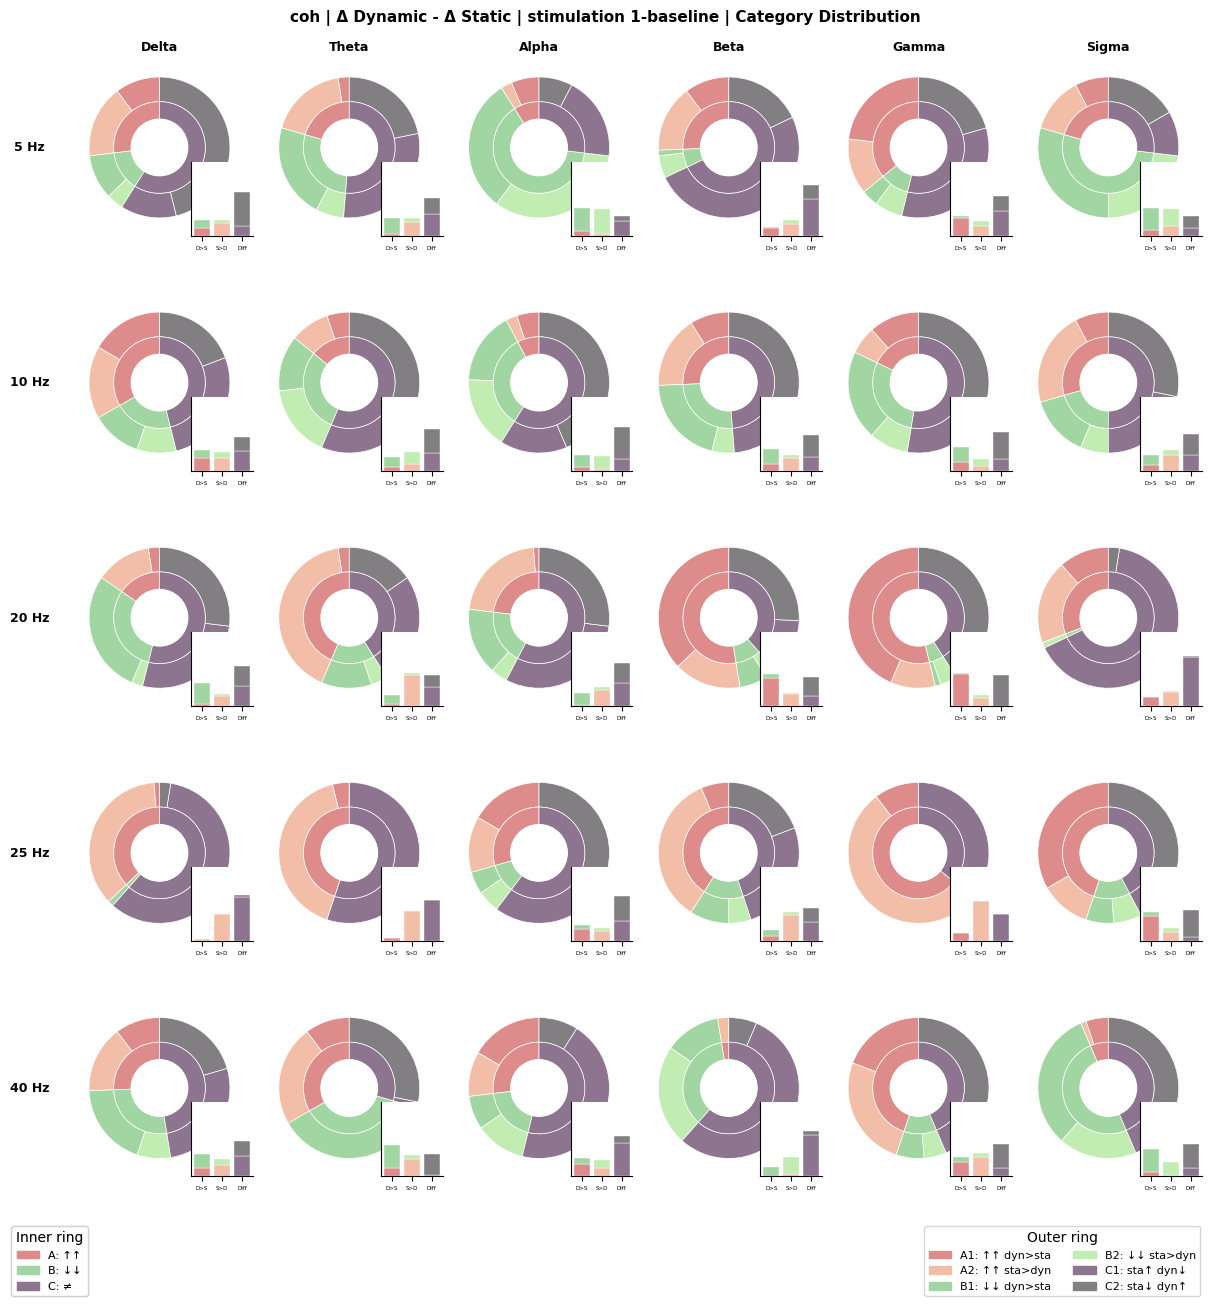

    Saved: figures/coh_deltaDynamic-Static_stimulation 1_pie.png
    Saved: figures/coh_deltaDynamic-Static_recovery 1_pie.png
Plotting wpli delta dynamic - delta static category pie chart figure...
    Saved: figures/wpli_deltaDynamic-Static_stimulation 1_pie.png
    Saved: figures/wpli_deltaDynamic-Static_recovery 1_pie.png
Plotting pli delta dynamic - delta static category pie chart figure...
    Saved: figures/pli_deltaDynamic-Static_stimulation 1_pie.png
    Saved: figures/pli_deltaDynamic-Static_recovery 1_pie.png
Plotting plv delta dynamic - delta static category pie chart figure...
    Saved: figures/plv_deltaDynamic-Static_stimulation 1_pie.png
    Saved: figures/plv_deltaDynamic-Static_recovery 1_pie.png
Plotting AEC delta dynamic - delta static category pie chart figure...
    Saved: figures/AEC_deltaDynamic-Static_stimulation 1_pie.png
    Saved: figures/AEC_deltaDynamic-Static_recovery 1_pie.png


In [26]:
# Figure: nested donut pie chart — edge category distribution per hz × band × stag

# ===== CONFIG =====
BASE = 'baseline'
TARG = ['stimulation 1', 'recovery 1']

CATEGORIES = ['A1', 'A2', 'B1', 'B2', 'C1', 'C2']
CAT_LABELS = ['A1: ↑↑ dyn>sta', 'A2: ↑↑ sta>dyn',
              'B1: ↓↓ dyn>sta', 'B2: ↓↓ sta>dyn',
              'C1: sta↑ dyn↓',  'C2: sta↓ dyn↑']
CAT_COLORS = ['#DD8B8B', '#F2BEA7', '#A1D6A2', '#C2EDB2', '#8D748F', '#817F82']

PARENT_MAP    = {'A1': 'A', 'A2': 'A', 'B1': 'B', 'B2': 'B', 'C1': 'C', 'C2': 'C'}
PARENT_COLORS = {'A': '#DD8B8B', 'B': '#A1D6A2', 'C': '#8D748F'}
PARENT_ORDER  = ['A', 'B', 'C']
PARENT_LABELS = ['A: ↑↑', 'B: ↓↓', 'C: ≠']

# Inset: 3 stacked bars
# bar0: A1(bottom) + B1(top)  → dyn wins
# bar1: A2(bottom) + B2(top)  → sta wins
# bar2: C1(bottom) + C2(top)  → diff dir
STACK_PAIRS  = [('A1', 'B1'), ('A2', 'B2'), ('C1', 'C2')]
STACK_COLORS = [('#DD8B8B', '#A1D6A2'), ('#F2BEA7', '#C2EDB2'), ('#8D748F', '#817F82')]

def categorize(ds, dd):
    if ds > 0 and dd > 0:
        return 'A1' if dd > ds else 'A2'
    elif ds < 0 and dd < 0:
        return 'B1' if dd > ds else 'B2'
    elif ds > 0 and dd < 0:
        return 'C1'
    else:
        return 'C2'

# ===== Plotting =====
for i, method in enumerate(METHODS):
    print(f"Plotting {method} delta dynamic - delta static category pie chart figure...") 
    for j, stag in enumerate(TARG):
        fig, axes = plt.subplots(len(HZS), len(BANDS),
                                figsize=(12,12),
                                subplot_kw=dict(aspect='equal'), layout='constrained')
        axes = np.atleast_2d(axes)

        for ri, hz in enumerate(HZS):
            df_s = out[method][(hz, 'static', stag)].merge(
                out[method][(hz, 'static', BASE)], on=['ch1', 'ch2', 'band'], suffixes=('_targ', '_base'))
            df_s['delta_static'] = df_s['value_targ'] - df_s['value_base']

            df_d = out[method][(hz, 'dynamic', stag)].merge(
                out[method][(hz, 'dynamic', BASE)], on=['ch1', 'ch2', 'band'], suffixes=('_targ', '_base'))
            df_d['delta_dynamic'] = df_d['value_targ'] - df_d['value_base']

            df = df_s[['ch1', 'ch2', 'band', 'delta_static']].merge(
                df_d[['ch1', 'ch2', 'band', 'delta_dynamic']], on=['ch1', 'ch2', 'band'])
            df['category'] = df.apply(lambda r: categorize(r['delta_static'], r['delta_dynamic']), axis=1)

            for ci, band in enumerate(BANDS):
                ax = axes[ri, ci]
                data = df[df['band'] == band]
                total = len(data)

                outer_counts = [len(data[data['category'] == c]) for c in CATEGORIES]
                inner_counts = [len(data[data['category'].map(PARENT_MAP) == p]) for p in PARENT_ORDER]

                ax.pie(outer_counts, colors=CAT_COLORS, startangle=90,
                    radius=1.0, wedgeprops=dict(edgecolor='white', linewidth=0.5, width=0.35))
                ax.pie(inner_counts, colors=[PARENT_COLORS[p] for p in PARENT_ORDER], startangle=90,
                    radius=0.65, wedgeprops=dict(edgecolor='white', linewidth=0.5, width=0.25))
                ax.add_patch(plt.Circle((0, 0), 0.4, color='white', zorder=3))

                # Inset: 3 stacked bars 
                inset = ax.inset_axes([0.68, 0.0, 0.35, 0.42])
                counts = {c: len(data[data['category'] == c]) / total if total else 0
                        for c in CATEGORIES}
                for xi, ((bot_cat, top_cat), (bot_col, top_col)) in enumerate(zip(STACK_PAIRS, STACK_COLORS)):
                    inset.bar(xi, counts[bot_cat], color=bot_col, edgecolor='white', linewidth=0.3)
                    inset.bar(xi, counts[top_cat], bottom=counts[bot_cat], color=top_col,
                            edgecolor='white', linewidth=0.3)
                inset.set_ylim(0, 1)
                inset.set_yticks([])
                inset.set_xticks([0, 1, 2])
                inset.set_xticklabels(['D>S', 'S>D', 'Diff'], fontsize=4)
                inset.tick_params(axis='y', labelsize=4)
                inset.spines[['top', 'right']].set_visible(False)

                if ri == 0:
                    ax.set_title(band, fontsize=9, fontweight='bold')
                if ci == 0:
                    ax.set_ylabel(f"{hz} Hz", fontsize=9, fontweight='bold',
                                rotation=0, labelpad=30, va='center')

        outer_handles = [plt.matplotlib.patches.Patch(color=c, label=l)
                        for c, l in zip(CAT_COLORS, CAT_LABELS)]
        inner_handles = [plt.matplotlib.patches.Patch(color=PARENT_COLORS[p], label=l)
                        for p, l in zip(PARENT_ORDER, PARENT_LABELS)]
        leg1 = fig.legend(handles=inner_handles, loc='lower left', fontsize=8,
                        title='Inner ring', bbox_to_anchor=(0.0, -0.08))
        leg2 = fig.legend(handles=outer_handles, loc='lower right', fontsize=8,
                        title='Outer ring', ncol=2, bbox_to_anchor=(1.0, -0.08))
        fig.add_artist(leg1)
        fig.suptitle(f"{method} | Δ Dynamic - Δ Static | {stag}-{BASE} | Category Distribution",
                    fontsize=11, fontweight='bold')
        png_path = f"{fig_path}/{method}_deltaDynamic-Static_{stag}_pie.png"
        fig.savefig(png_path, dpi=150, bbox_inches='tight')
        if i == 0 and j ==0 : # preview
            plt.show()
        plt.close(fig)
        print(f"    Saved: {png_path}")